In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
import math
import random

## 1. Configuration

In [20]:
# Maze Image Path
IMAGE_PATH = Path("images/Official_4.2.jpg")

# Maze Parameters
ROWS = 9
COLS = 9
CELL_SIZE_MM = 180

# Maze start/goal and the obstacle course bounds are entered by the user.
MAZE_START = None               # (row, col, heading)
MAZE_GOAL = None                # (row, col)
OBSTACLE_ROW_RANGE = None       # (first row, last row)
OBSTACLE_COL_RANGE = None       # (first col, last col)

# Obstacle course entry/exit cells are found from the wall grid.
OBSTACLE_ENTRY = None
OBSTACLE_EXIT = None

# Wall Mask Inflation Factor for RRT* (as a fraction of a cell)
OBSTACLE_INFLATION_FACTOR = 0.33     # obstacles inside the course
WALL_INFLATION_FACTOR = 0.33         # inner walls of the obstacle course

# RRT* Parameters
RRT_SEED = 42                   # random seed for reproducibility
RRT_MAX_NODES = 1500            # tree nodes before giving up
RRT_MAX_ITERATIONS = 60000      # hard loop cap so a bad mask can never hang the notebook
RRT_STEP_SIZE = 130             # px the tree grows per sample
RRT_NEIGHBOUR_RADIUS = 260      # px radius used for choosing a parent / rewiring
RRT_GOAL_RADIUS = 200           # px within which the goal is connected directly
RRT_ROI_MARGIN_CELLS = 0.3      # how far outside the obstacle block sampling may stray

# Color Definitions (BGR)
BLUE =      (255, 0, 0)
GREEN =     (0, 255, 0)
RED =       (0, 0, 255)
MAGENTA =   (255, 0, 255)
YELLOW =    (0, 255, 255)
ORANGE =    (0, 165, 255)

## 2. Image Capture

In [21]:
image = cv2.imread(str(IMAGE_PATH))

# Allows the user to select the four corners coordinates of the maze on the image.
display = image.copy()
points = []

def click_point(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4:
        points.append((x, y))

        cv2.circle(display, (x, y), 8, RED, -1)
        cv2.putText(display, str(len(points)), (x + 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, RED, 2)
        cv2.imshow("Select maze corners", display)

print("Click the maze corners in order: top-left, top-right, bottom-right, bottom-left.")

cv2.namedWindow("Select maze corners", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Select maze corners", 1600, 900)
cv2.imshow("Select maze corners", display)

cv2.setMouseCallback("Select maze corners", click_point)

# Close the window automatically once four corners have been clicked (Esc to abort)
while len(points) < 4:
    if cv2.waitKey(20) & 0xFF == 27:
        break

cv2.destroyAllWindows()
for _ in range(4):
    cv2.waitKey(1)

if len(points) != 4:
    raise ValueError("Four corners are required to rectify the maze.")

maze_corners = list(points)
print("Selected points:", maze_corners)

Click the maze corners in order: top-left, top-right, bottom-right, bottom-left.
Selected points: [(617, 183), (1340, 196), (1324, 913), (610, 908)]


## 3. Coordinate Entry

In [22]:
# HELPERS: Convert between cell coordinates and node IDs
def cell_to_id(row, col): return row * COLS + col
def id_to_cell(node_id): return divmod(node_id, COLS)

# HELPER: Checks if a cell is in the obstacle region
def in_obstacle_region(row, col):
    return (OBSTACLE_ROW_RANGE[0] <= row <= OBSTACLE_ROW_RANGE[1]
            and OBSTACLE_COL_RANGE[0] <= col <= OBSTACLE_COL_RANGE[1])

# HELPER: Asks the user to input cell coordinates for Task 4.2
def ask_cell(prompt, count):
    while True:
        parts = [p.strip() for p in input(prompt).split(",")]
        if len(parts) != count:
            print(f"  Enter {count} comma-separated values.")
            continue
        try:
            return [int(p) for p in parts[:2]] + parts[2:]
        except ValueError:
            print("  Row and column must be whole numbers.")

row, col, heading = ask_cell("Maze start (row,col,heading): ", 3)
MAZE_START = (row, col, heading.upper())

row, col = ask_cell("Maze goal (row,col): ", 2)
MAZE_GOAL = (row, col)

row, col = ask_cell("Obstacle course top-left cell (row,col): ", 2)
course_top_left = (row, col)

row, col = ask_cell("Obstacle course bottom-right cell (row,col): ", 2)
course_bottom_right = (row, col)

OBSTACLE_ROW_RANGE = (course_top_left[0], course_bottom_right[0])
OBSTACLE_COL_RANGE = (course_top_left[1], course_bottom_right[1])

block_rows = OBSTACLE_ROW_RANGE[1] - OBSTACLE_ROW_RANGE[0] + 1
block_cols = OBSTACLE_COL_RANGE[1] - OBSTACLE_COL_RANGE[0] + 1
if (block_rows, block_cols) != (5, 5):
    print(f"!! Obstacle course is {block_rows}x{block_cols}, expected 5x5")

print("Coordinates entered by the user:")
print(f" Maze Start:     {MAZE_START}")
print(f" Maze Goal:      {MAZE_GOAL}")
print(f" Course Rows:    {OBSTACLE_ROW_RANGE}")
print(f" Course Cols:    {OBSTACLE_COL_RANGE}")

Coordinates entered by the user:
 Maze Start:     (1, 1, 'S')
 Maze Goal:      (5, 7)
 Course Rows:    (0, 4)
 Course Cols:    (2, 6)


## 4. Image Rectification

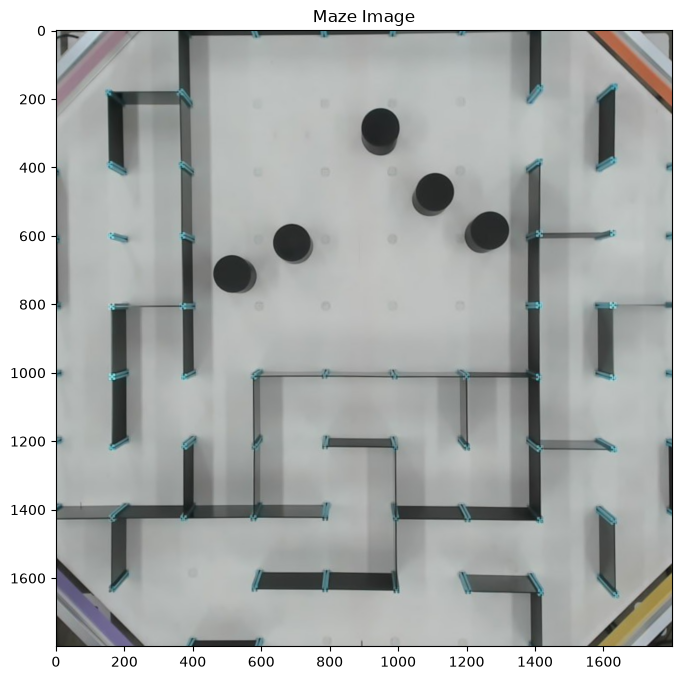

In [23]:
# Transform the maze image to a top-down view using the four corners coordinates.
source_points = np.float32(maze_corners)

output_width = 1800
output_height = 1800

destination_points = np.float32([
    [0, 0],
    [output_width - 1, 0],
    [output_width - 1, output_height - 1],
    [0, output_height - 1],
])

H = cv2.getPerspectiveTransform(source_points, destination_points)

rectified_bgr = cv2.warpPerspective(image, H, (output_width, output_height))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(rectified_bgr, cv2.COLOR_BGR2RGB))
plt.title("Maze Image")
plt.show()

## 5. Wall Mask

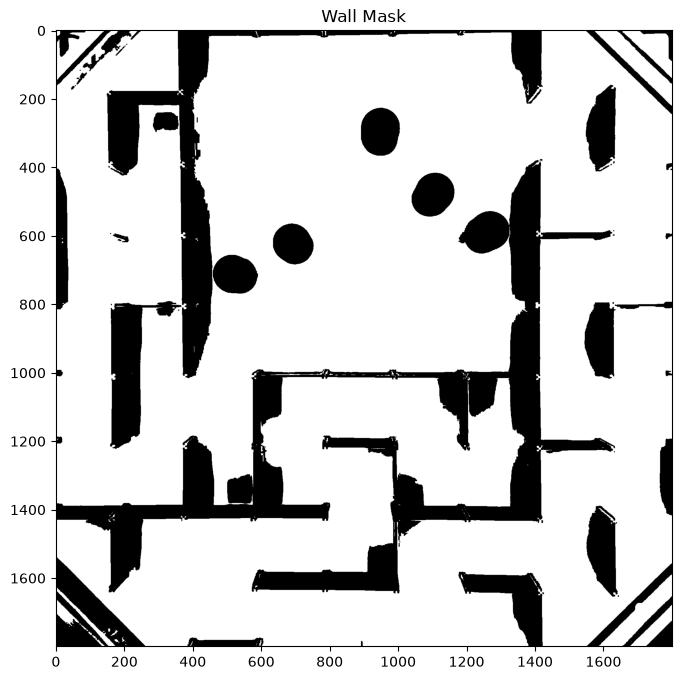

In [24]:
# Create a wall mask by thresholding the rectified maze image in HSV color space.

grid_hsv = cv2.cvtColor(rectified_bgr, cv2.COLOR_BGR2HSV)

lower_hsv = np.array([0, 0, 150])       # Increase V to increase mask affect
upper_hsv = np.array([180, 255, 255])

# White means bright floor
wall_mask = cv2.inRange(grid_hsv, lower_hsv, upper_hsv)

kernel = np.ones((3, 3), np.uint8)

# Connect small gaps without excessively thickening everything
wall_mask = cv2.morphologyEx(wall_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

plt.figure(figsize=(8, 8))
plt.imshow(wall_mask, cmap="gray")
plt.title("Wall Mask")
plt.show()

## 6. Wall Detection

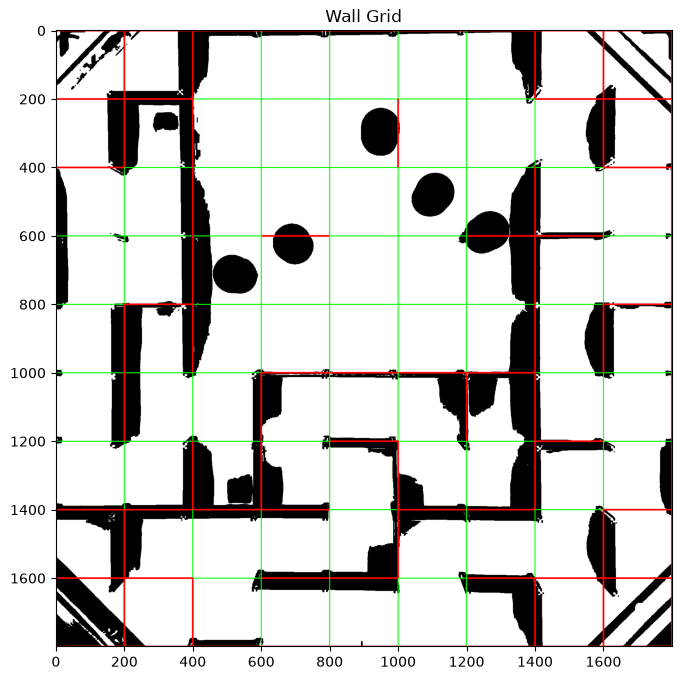

In [25]:
# HELPER: Return true if a black line exists between two points in the image
def black_line_exists(image, x1, y1, x2, y2, horizontal, width):
    img_h, img_w = image.shape[:2]
    half = width // 2

    def line_all_black(ax1, ay1, ax2, ay2):
        length = int(max(abs(ax2 - ax1), abs(ay2 - ay1)))
        if length == 0:
            return np.all(image[int(ay1), int(ax1)] < 128)
        for i in range(length + 1):
            t = i / length
            x = int(round(ax1 + t * (ax2 - ax1)))
            y = int(round(ay1 + t * (ay2 - ay1)))
            if not np.all(image[y, x] == 0):  # pixel isn't black -> line broken
                return False
        return True

    for offset in range(-half, half + 1):
        if horizontal:
            ox1, oy1 = x1, y1 + offset
            ox2, oy2 = x2, y2 + offset
        else:
            ox1, oy1 = x1 + offset, y1
            ox2, oy2 = x2 + offset, y2

        # Skip offset lines that fall outside the image
        if not (0 <= ox1 < img_w and 0 <= ox2 < img_w and
                0 <= oy1 < img_h and 0 <= oy2 < img_h):
            continue

        if line_all_black(ox1, oy1, ox2, oy2):
            return True

    return False

# Compute the cell dimensions in pixels based on the wall mask size and the number of rows and columns.
height, width = wall_mask.shape

cell_h = height / ROWS
cell_w = width / COLS

SAMPLE_THICKNESS = 80   # Band thickness to scan perpendicular to each boundary (half either side)
SAMPLE_MARGIN = 0.25    # Exclude 25% from each end of the cell boundary

# Helper: Manually block a cell by setting all four walls to True.
def block_cell(row, col):
    # Top and bottom walls
    horizontal_walls[row, col] = True
    horizontal_walls[row + 1, col] = True

    # Left and right walls
    vertical_walls[row, col] = True
    vertical_walls[row, col + 1] = True

# --- Horizontal boundaries: (ROWS + 1) x COLS ---
horizontal_walls = np.zeros((ROWS + 1, COLS), dtype=bool)

for r in range(ROWS + 1):
    # Expected y-coordinate of the horizontal boundary
    y_boundary = int(r * cell_h)

    for c in range(COLS):
        # Force the top and bottom outer boundaries to be walls
        if r == 0 or r == ROWS:
            horizontal_walls[r, c] = True
            continue

        # Endpoints of the segment along the boundary (middle portion of the cell width)
        x1 = int((c + SAMPLE_MARGIN) * cell_w)
        x2 = int((c + 1 - SAMPLE_MARGIN) * cell_w)

        horizontal_walls[r, c] = black_line_exists(
            wall_mask, x1, y_boundary, x2, y_boundary,
            horizontal=True, width=SAMPLE_THICKNESS
        )

# --- Vertical boundaries: ROWS x (COLS + 1) ---
vertical_walls = np.zeros((ROWS, COLS + 1), dtype=bool)

for r in range(ROWS):
    for c in range(COLS + 1):
        # Force the left and right outer boundaries to be walls
        if c == 0 or c == COLS:
            vertical_walls[r, c] = True
            continue
        
        # Expected x-coordinate of the vertical boundary
        x_boundary = int(c * cell_w)

        # Endpoints of the segment along the boundary (middle portion of the cell height)
        y1 = int((r + SAMPLE_MARGIN) * cell_h)
        y2 = int((r + 1 - SAMPLE_MARGIN) * cell_h)

        vertical_walls[r, c] = black_line_exists(
            wall_mask, x_boundary, y1, x_boundary, y2,
            horizontal=False, width=SAMPLE_THICKNESS
        )

# Block the corner cells
block_cell(0, 0) # Top-left corner cell
block_cell(0, 1) # Node 1 cell
block_cell(1, 0) # Node 9 cell
block_cell(0, COLS - 1) # Top-right corner cell
block_cell(0, COLS - 2) # Node 7 cell
block_cell(1, COLS - 1) # Node 17 cell
block_cell(ROWS - 1, 0) # Bottom-left corner cell
block_cell(ROWS - 2, 0) # Node 63 cell
block_cell(ROWS - 1, 1) # Node 73 cell
block_cell(ROWS - 1, COLS - 1) # Bottom-right corner cell
block_cell(ROWS - 2, COLS - 1) # Node 71 cell
block_cell(ROWS - 1, COLS - 2) # Node 79 cell

# Display detected walls and open boundaries ----------------------------------

# Convert the grayscale mask to BGR so coloured lines can be drawn
wall_grid = cv2.cvtColor(wall_mask, cv2.COLOR_GRAY2BGR)

# Draw horizontal boundaries
for r in range(ROWS + 1):
    for c in range(COLS):

        x1 = int(c * cell_w)
        x2 = int((c + 1) * cell_w)
        y = int(r * cell_h)

        colour, thickness = (RED, 4) if horizontal_walls[r, c] else (GREEN, 2)
        cv2.line(wall_grid, (x1, y), (x2, y), colour, thickness)

# Draw vertical boundaries
for r in range(ROWS):
    for c in range(COLS + 1):

        x = int(c * cell_w)
        y1 = int(r * cell_h)
        y2 = int((r + 1) * cell_h)

        colour, thickness = (RED, 4) if vertical_walls[r, c] else (GREEN, 2)
        cv2.line(wall_grid, (x, y1), (x, y2), colour, thickness)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(wall_grid, cv2.COLOR_BGR2RGB))
plt.title("Wall Grid")
plt.show()

## 7. Maze Graph

In [26]:
# Graph Class

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y

    def get_point(self):
        return (self.x, self.y)

    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 not in self.nodes or node_id2 not in self.nodes:
            return
        self.edges[node_id1][node_id2] = weight
        self.edges[node_id2][node_id1] = weight

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges:
            self.edges[node_id1].pop(node_id2, None)
        if node_id2 in self.edges:
            self.edges[node_id2].pop(node_id1, None)

    def get_nodes(self):
        return self.nodes

    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 not in self.edges:
            return None
        return self.edges[node_id1].get(node_id2)

In [27]:
# Find the obstacle course entry/exit cells from the wall grid.

# Every gap in the perimeter of the obstacle block, as (inside cell, outside cell).
def region_openings():
    openings = []

    for row in range(OBSTACLE_ROW_RANGE[0], OBSTACLE_ROW_RANGE[1] + 1):
        for col in range(OBSTACLE_COL_RANGE[0], OBSTACLE_COL_RANGE[1] + 1):
            sides = [
                (row - 1, col, horizontal_walls[row, col]),          # north
                (row + 1, col, horizontal_walls[row + 1, col]),      # south
                (row, col - 1, vertical_walls[row, col]),            # west
                (row, col + 1, vertical_walls[row, col + 1]),        # east
            ]
            for nr, nc, walled in sides:
                if (0 <= nr < ROWS and 0 <= nc < COLS and not walled
                        and not in_obstacle_region(nr, nc)):
                    openings.append(((row, col), (nr, nc)))

    return openings

# Cell distances from a starting cell, travelling only outside the obstacle block.
def maze_distances(start_cell):
    dist = {start_cell: 0}
    q = deque([start_cell])

    while q:
        row, col = q.popleft()
        sides = [
            (row - 1, col, horizontal_walls[row, col]),
            (row + 1, col, horizontal_walls[row + 1, col]),
            (row, col - 1, vertical_walls[row, col]),
            (row, col + 1, vertical_walls[row, col + 1]),
        ]
        for nr, nc, walled in sides:
            if (0 <= nr < ROWS and 0 <= nc < COLS and not walled
                    and (nr, nc) not in dist and not in_obstacle_region(nr, nc)):
                dist[(nr, nc)] = dist[(row, col)] + 1
                q.append((nr, nc))

    return dist

# Openings ranked by how far their outside cell is from the given cell.
# Unreachable openings fall back to Manhattan distance so they rank last but stay ordered.
def rank_openings(openings, from_cell):
    dist = maze_distances(from_cell)
    ranked = []

    for inside, outside in openings:
        manhattan = abs(outside[0] - from_cell[0]) + abs(outside[1] - from_cell[1])
        ranked.append((dist.get(outside, ROWS * COLS + manhattan), inside))

    ranked.sort()
    return ranked

course_openings = region_openings()

if not course_openings:
    raise ValueError("No gap found in the obstacle course perimeter - check the wall grid.")

# Entry is the opening nearest the maze start, exit the opening nearest the maze goal
ranked_from_start = rank_openings(course_openings, (MAZE_START[0], MAZE_START[1]))
ranked_from_goal = rank_openings(course_openings, MAZE_GOAL)

OBSTACLE_ENTRY = ranked_from_start[0][1]
OBSTACLE_EXIT = next((cell for _, cell in ranked_from_goal if cell != OBSTACLE_ENTRY),
                     ranked_from_goal[0][1])

OBSTACLE_ENTRY_ID = cell_to_id(*OBSTACLE_ENTRY)
OBSTACLE_EXIT_ID = cell_to_id(*OBSTACLE_EXIT)

print(f"Perimeter gaps: {[inside for inside, _ in course_openings]}")
print(f"Course Entry:   {OBSTACLE_ENTRY}    -> node {OBSTACLE_ENTRY_ID}")
print(f"Course Exit:    {OBSTACLE_EXIT}    -> node {OBSTACLE_EXIT_ID}")

Perimeter gaps: [(1, 6), (4, 2)]
Course Entry:   (4, 2)    -> node 38
Course Exit:    (1, 6)    -> node 15


course entry (4, 2) connects to [(5, 2)]
course exit (1, 6) connects to [(1, 7)]


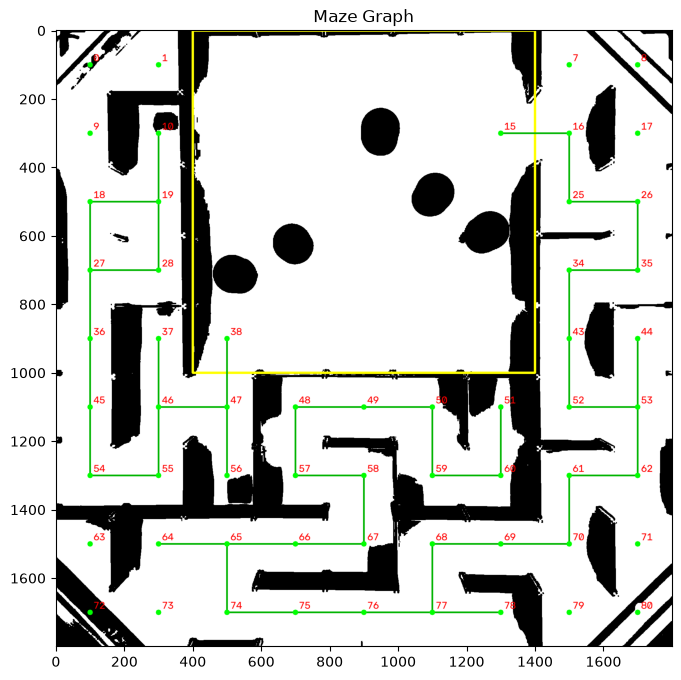

In [28]:
def cell_centre(row, col):
    """Pixel centre of a maze cell in the rectified image."""
    return (int((col + 0.5) * cell_w), int((row + 0.5) * cell_h))

# Cells inside the obstacle block are excluded from the discrete graph so BFS
# can never plan a straight line through the obstacle field.
def cell_in_graph(row, col):
    if not in_obstacle_region(row, col):
        return True
    return (row, col) in (OBSTACLE_ENTRY, OBSTACLE_EXIT)

maze_graph = Graph()

for row in range(ROWS):
    for col in range(COLS):
        if not cell_in_graph(row, col):
            continue
        x, y = cell_centre(row, col)
        maze_graph.add_node(cell_to_id(row, col), x, y)

for row in range(ROWS):
    for col in range(COLS):

        current_id = cell_to_id(row, col)

        # Check the cell to the right
        if col < COLS - 1 and not vertical_walls[row, col + 1]:
            maze_graph.add_edge(current_id, current_id + 1, 1)

        # Check the cell below
        if row < ROWS - 1 and not horizontal_walls[row + 1, col]:
            maze_graph.add_edge(current_id, current_id + COLS, 1)

# Never let BFS hop straight from the entry to the exit if they happen to be adjacent -
# that transition belongs to RRT*.
maze_graph.remove_edge(OBSTACLE_ENTRY_ID, OBSTACLE_EXIT_ID)

# Sanity check: the entry and the exit must each border at least one open cell OUTSIDE
# the obstacle block, otherwise BFS has no way in or out and a leg comes back empty.
def openings_outside_region(row, col):
    found = []
    neighbours = [
        (row - 1, col, not horizontal_walls[row, col]),          # north
        (row + 1, col, not horizontal_walls[row + 1, col]),      # south
        (row, col - 1, not vertical_walls[row, col]),            # west
        (row, col + 1, not vertical_walls[row, col + 1]),        # east
    ]
    for r, c, open_side in neighbours:
        if 0 <= r < ROWS and 0 <= c < COLS and open_side and not in_obstacle_region(r, c):
            found.append((r, c))
    return found

for label, cell in [("entry", OBSTACLE_ENTRY), ("exit", OBSTACLE_EXIT)]:
    ways = openings_outside_region(*cell)
    if ways:
        print(f"course {label} {cell} connects to {ways}")
    else:
        print(f"!! course {label} {cell} has no open neighbour outside the obstacle block - "
              f"BFS cannot reach it. Move it to the border of the block, or shrink the block.")

# Draw all graph edges
graph_overlay = cv2.cvtColor(wall_mask, cv2.COLOR_GRAY2BGR)

# Shade the obstacle course region
roi_tl = (int(OBSTACLE_COL_RANGE[0] * cell_w), int(OBSTACLE_ROW_RANGE[0] * cell_h))
roi_br = (int((OBSTACLE_COL_RANGE[1] + 1) * cell_w), int((OBSTACLE_ROW_RANGE[1] + 1) * cell_h))
cv2.rectangle(graph_overlay, roi_tl, roi_br, YELLOW, 6)

for node_id_1, neighbours in maze_graph.edges.items():
    point_1 = maze_graph.get_nodes()[node_id_1].get_point()
    for node_id_2 in neighbours:
        if node_id_1 < node_id_2:
            point_2 = maze_graph.get_nodes()[node_id_2].get_point()
            cv2.line(graph_overlay, point_1, point_2, (0, 180, 0), 4)

# Draw all graph nodes
for node in maze_graph.get_nodes().values():
    cv2.circle(graph_overlay, node.get_point(), 8, GREEN, -1)
    cv2.putText(graph_overlay, str(node.get_ID()),
        (node.get_point()[0] + 10, node.get_point()[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX, 1, RED, 1)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(graph_overlay, cv2.COLOR_BGR2RGB))
plt.title("Maze Graph")
plt.show()

## 8. BFS Implementation

In [29]:
# Implements BFS

def bfs(graph, start_node_id, end_node_id):
    path = []

    if start_node_id not in graph.get_nodes() or end_node_id not in graph.get_nodes():
        return path

    q = deque()
    cost = {start_node_id: 0}
    parent = {start_node_id: -1}

    q.append(start_node_id)

    while q:
        currNode = q.popleft()

        if currNode == end_node_id:
            break  # Stop if we reach the end node

        for adj in graph.edges[currNode]:
            if adj not in cost:  # Not visited
                cost[adj] = cost[currNode] + 1
                parent[adj] = currNode
                q.append(adj)

    # If the end node is unreachable
    if end_node_id not in cost:
        return path

    # Reconstruct the shortest path
    currNode = end_node_id
    while currNode != -1:
        path.append(currNode)
        if currNode == start_node_id:
            break
        currNode = parent[currNode]

    path.reverse()
    return path

## 9. Mask Inflation for RRT*

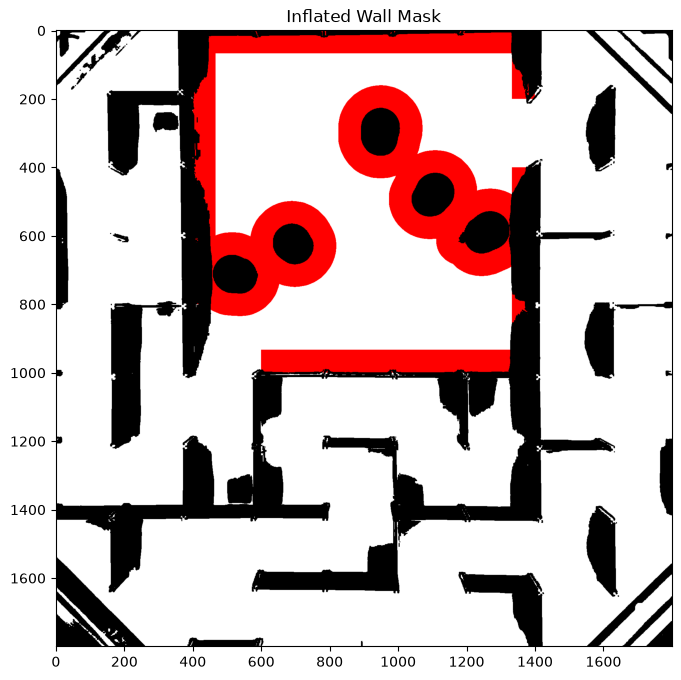

In [30]:
# Wall mask inflated for RRT* path planning only - the original wall_mask is untouched.
PX_PER_MM = output_width / (COLS * CELL_SIZE_MM)
MM_PER_PX = 1.0 / PX_PER_MM

# Define the area whose obstacles should be inflated
CROP_BUFFER_PX = 80

roi_top_left = (
    int(course_top_left[1] * 200 + CROP_BUFFER_PX),
    int(course_top_left[0] * 200 + CROP_BUFFER_PX)
)

roi_bottom_right = (
    int((course_bottom_right[1] + 1) * 200 - CROP_BUFFER_PX),
    int((course_bottom_right[0] + 1) * 200 - CROP_BUFFER_PX)
)

x1, y1 = roi_top_left
x2, y2 = roi_bottom_right

# Create the inflation kernel
inflation_px = int(round(OBSTACLE_INFLATION_FACTOR * cell_w))
inflation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * inflation_px + 1, 2 * inflation_px + 1))

# Keep only walls inside the selected region but keep the image at FULL SIZE
selected_walls = np.full_like(wall_mask, 255)           # Start with completely free space
selected_walls[y1:y2, x1:x2] = wall_mask[y1:y2, x1:x2]  # Copy the original mask only inside the selected area

# Inflate those selected walls
selected_walls = cv2.medianBlur(selected_walls, 5)
inflated_selected_walls = cv2.erode(selected_walls, inflation_kernel)

# The inner walls of the obstacle course are inflated as a solid band drawn just inside
# the yellow course boundary, rather than by eroding the mask.
mask_h, mask_w = wall_mask.shape[:2]

block_x1 = max(int(OBSTACLE_COL_RANGE[0] * cell_w), 0)
block_y1 = max(int(OBSTACLE_ROW_RANGE[0] * cell_h), 0)
block_x2 = min(int((OBSTACLE_COL_RANGE[1] + 1) * cell_w), mask_w)
block_y2 = min(int((OBSTACLE_ROW_RANGE[1] + 1) * cell_h), mask_h)

wall_inflation_px = int(round(WALL_INFLATION_FACTOR * cell_w))

# Draw the band at double thickness on the course boundary, then keep only the half that
# falls inside the course, so the band is exactly wall_inflation_px thick and the rest of
# the maze is left untouched.
course_wall_band = np.full_like(wall_mask, 255)

if wall_inflation_px > 0:
    cv2.rectangle(course_wall_band,
                  (block_x1, block_y1), (block_x2 - 1, block_y2 - 1),
                  0, 2 * wall_inflation_px)

    inflated_course_walls = np.full_like(wall_mask, 255)
    inflated_course_walls[block_y1:block_y2, block_x1:block_x2] = \
        course_wall_band[block_y1:block_y2, block_x1:block_x2]
else:
    inflated_course_walls = course_wall_band

# HELPER: Free a whole cell from the inner wall band
def clear_cell_inflation(mask, cell):
    row, col = cell
    cx1 = max(int(col * cell_w), 0)
    cy1 = max(int(row * cell_h), 0)
    cx2 = min(int((col + 1) * cell_w), mask_w)
    cy2 = min(int((row + 1) * cell_h), mask_h)
    mask[cy1:cy2, cx1:cx2] = 255

# The entry and exit cells keep their original clearance so the band can never seal
# the way into or out of the obstacle course.
for course_cell in (OBSTACLE_ENTRY, OBSTACLE_EXIT):
    clear_cell_inflation(inflated_course_walls, course_cell)

# Combine FULL inflation with original wall mask
inflated_wall_mask = cv2.bitwise_and(wall_mask, inflated_selected_walls)
inflated_wall_mask = cv2.bitwise_and(inflated_wall_mask, inflated_course_walls)

# RRT* free-space image
free_space = cv2.cvtColor(inflated_wall_mask, cv2.COLOR_GRAY2BGR)

def is_free(image, x, y):
    return np.array_equal(image[int(y), int(x)], [255, 255, 255])

rrt_start_location = cell_centre(*OBSTACLE_ENTRY)
rrt_goal_location = cell_centre(*OBSTACLE_EXIT)

# Red = space lost to inflation
inflated_display = cv2.cvtColor(wall_mask, cv2.COLOR_GRAY2BGR)
inflated_display[wall_mask != inflated_wall_mask] = RED

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(inflated_display, cv2.COLOR_BGR2RGB))
plt.title("Inflated Wall Mask")
plt.show()

## 10. RRT* Implementation

In [31]:
# HELPER: Returns true/false if the path is clear between two points
def path_clear(image, x1, y1, x2, y2):
    length = int(max(abs(x2 - x1), abs(y2 - y1)))
    if length == 0:
        return True
    for i in range(length + 1):
        t = i / length
        x = int(round(x1 + t * (x2 - x1)))
        y = int(round(y1 + t * (y2 - y1)))
        if not np.array_equal(image[y, x], [255, 255, 255]):
            return False
    return True

# HELPER: Extends the tree from a point by step / cartesian distance
def calculate_new_tree_point(x_closest, y_closest, x, y, step):
    dist = math.hypot(x - x_closest, y - y_closest)
    if dist <= step:
        return x, y, dist
    ratio = step / dist
    x_new = x_closest + ratio * (x - x_closest)
    y_new = y_closest + ratio * (y - y_closest)
    return x_new, y_new, step

# HELPER: Finds and returns the closest node to a point on the image
def find_closest_node_rrt(graph, target_x, target_y):
    best_id, best_dist = None, float('inf')
    for node_id, node in graph.nodes.items():
        x, y = node.get_point()
        dist = math.hypot(x - target_x, y - target_y)
        if dist < best_dist:
            best_dist = dist
            best_id = node_id
    return best_id

# HELPER: Returns all node IDs within radius from the given point
def nodes_within_radius(graph, x, y, radius):
    result = []
    for node_id, node in graph.nodes.items():
        nx, ny = node.get_point()
        if math.hypot(nx - x, ny - y) <= radius:
            result.append(node_id)
    return result

# HELPER: Updates costs down a subtree after rewiring with BFS
def propagate_cost(graph, cost, parent, root, came_from):
    queue = deque([(root, came_from)])
    while queue:
        curr, prev = queue.popleft()
        for neighbor in graph.edges[curr]:
            if neighbor != prev and parent.get(neighbor) == curr:
                cost[neighbor] = cost[curr] + graph.edges[curr][neighbor]
                queue.append((neighbor, curr))

In [32]:
def rrt_star(image, start_location, goal_location,
             seed=RRT_SEED,
             max_nodes=RRT_MAX_NODES,
             max_iterations=RRT_MAX_ITERATIONS,
             step_size=RRT_STEP_SIZE,
             neighbour_radius=RRT_NEIGHBOUR_RADIUS,
             goal_radius=RRT_GOAL_RADIUS,
             sample_roi=None):
    
    rrt_graph = Graph()
    random.seed(seed)

    if sample_roi is None:
        sample_roi = (0, 0, image.shape[1] - 1, image.shape[0] - 1)
    x_min, y_min, x_max, y_max = [int(v) for v in sample_roi]

    # Root the tree at the start location (node ID -1)
    rrt_graph.add_node(-1, *start_location)
    parent = {-1: None}
    cost = {-1: 0}

    goal_connected = False
    node_count = 0
    iterations = 0

    while node_count < max_nodes and not goal_connected and iterations < max_iterations:
        iterations += 1

        # Bias a few samples straight at the goal so the tree actually heads somewhere
        if random.random() < 0.05:
            x_rand, y_rand = goal_location
        else:
            x_rand = random.randint(x_min, x_max)
            y_rand = random.randint(y_min, y_max)

        # Finds the node nearest to the random point and extends towards it
        nearest_id = find_closest_node_rrt(rrt_graph, x_rand, y_rand)
        x_near, y_near = rrt_graph.nodes[nearest_id].get_point()
        x_new, y_new, _ = calculate_new_tree_point(x_near, y_near, x_rand, y_rand, step_size)
        x_new, y_new = int(x_new), int(y_new)

        # Skips invalid samples not in free-space
        if not is_free(image, x_new, y_new):
            continue

        # Picks a valid parent from nearby nodes with the lowest cost
        nearby = nodes_within_radius(rrt_graph, x_new, y_new, neighbour_radius)
        best_parent = None
        best_cost = float('inf')
        for cand_id in nearby:
            cx, cy = rrt_graph.nodes[cand_id].get_point()
            dist = math.hypot(x_new - cx, y_new - cy)
            if path_clear(image, cx, cy, x_new, y_new) and cost[cand_id] + dist < best_cost:
                best_parent = cand_id
                best_cost = cost[cand_id] + dist

        # Skips if no valid parent was found (no connection to the tree)
        if best_parent is None:
            continue

        # Adds the new node and connects it to the best parent
        new_id = node_count
        px, py = rrt_graph.nodes[best_parent].get_point()
        rrt_graph.add_node(new_id, x_new, y_new)
        rrt_graph.add_edge(best_parent, new_id, math.hypot(x_new - px, y_new - py))

        parent[new_id] = best_parent
        cost[new_id] = best_cost
        node_count += 1

        # Rewires nearby nodes if the edge through the new node is cheaper
        for cand_id in nearby:
            if cand_id == best_parent:
                continue
            cx, cy = rrt_graph.nodes[cand_id].get_point()
            dist = math.hypot(x_new - cx, y_new - cy)
            if cost[new_id] + dist < cost[cand_id] and path_clear(image, x_new, y_new, cx, cy):
                old_parent = parent[cand_id]
                rrt_graph.remove_edge(old_parent, cand_id)
                rrt_graph.add_edge(new_id, cand_id, dist)
                parent[cand_id] = new_id
                cost[cand_id] = cost[new_id] + dist
                propagate_cost(rrt_graph, cost, parent, cand_id, new_id)

        # Checks if the goal can be connected directly from the new node
        gx, gy = goal_location
        goal_dist = math.hypot(gx - x_new, gy - y_new)
        if goal_dist <= goal_radius and path_clear(image, x_new, y_new, gx, gy):
            rrt_graph.add_node(-2, gx, gy)
            rrt_graph.add_edge(new_id, -2, goal_dist)
            parent[-2] = new_id
            cost[-2] = cost[new_id] + goal_dist
            goal_connected = True

    # Reconstructs the path from start to goal
    ids = []
    if goal_connected:
        node = -2
        while node is not None:
            ids.append(node)
            node = parent[node]
        ids.reverse()

    points = [rrt_graph.nodes[i].get_point() for i in ids]
    print(f"RRT*:\n {node_count} nodes\n {iterations} iterations\n"
          f" goal {'connected' if goal_connected else 'NOT connected'}"
          + (f"\n cost {cost[-2]:.0f} px" if goal_connected else ""))
    return points, rrt_graph, goal_connected

## 11. Path Generation

In [33]:
# Repeatedly skip intermediate waypoints while the straight line between the survivors stays inside free space.
def shortcut_path(image, points):
    if len(points) < 3:
        return list(points)
    result = [points[0]]
    i = 0
    while i < len(points) - 1:
        j = len(points) - 1
        while j > i + 1 and not path_clear(image, *result[-1], *points[j]):
            j -= 1
        result.append(points[j])
        i = j
    return result

MAZE_START_ID = cell_to_id(MAZE_START[0], MAZE_START[1])
MAZE_GOAL_ID = cell_to_id(*MAZE_GOAL)

# Restrict RRT* sampling to the obstacle block plus a margin.
margin_x = RRT_ROI_MARGIN_CELLS * cell_w
margin_y = RRT_ROI_MARGIN_CELLS * cell_h

sample_roi = (
    max(0, OBSTACLE_COL_RANGE[0] * cell_w - margin_x),
    max(0, OBSTACLE_ROW_RANGE[0] * cell_h - margin_y),
    min(width - 1, (OBSTACLE_COL_RANGE[1] + 1) * cell_w + margin_x),
    min(height - 1, (OBSTACLE_ROW_RANGE[1] + 1) * cell_h + margin_y),
)

leg1_cells = bfs(maze_graph, MAZE_START_ID, OBSTACLE_ENTRY_ID)

leg2_points, rrt_graph, rrt_ok = rrt_star(
    free_space, rrt_start_location, rrt_goal_location, sample_roi=sample_roi
)
leg2_points = shortcut_path(free_space, leg2_points)

leg3_cells = bfs(maze_graph, OBSTACLE_EXIT_ID, MAZE_GOAL_ID)

RRT*:
 36 nodes
 79 iterations
 goal connected
 cost 1482 px


## 12. Path Visualisation

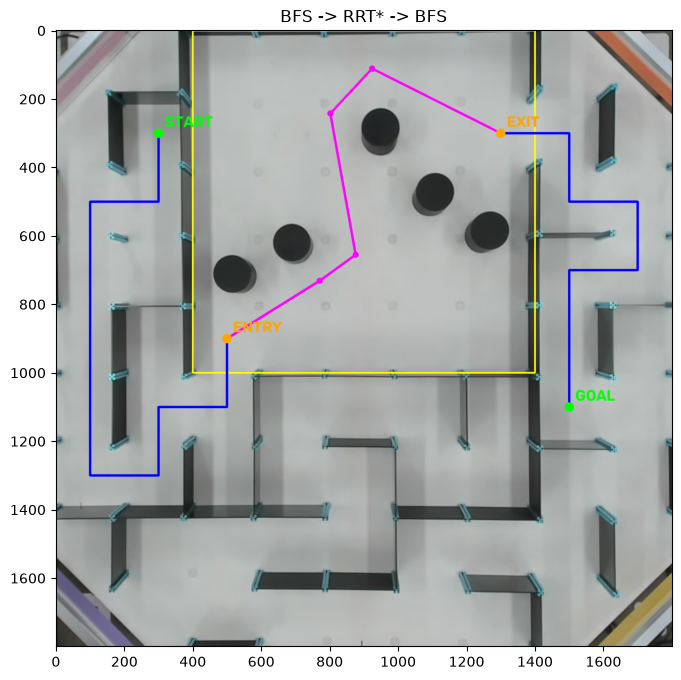

In [34]:
# One figure showing all three legs, on the rectified maze photo.
path_on_maze = rectified_bgr.copy()

# Obstacle course region
cv2.rectangle(path_on_maze, roi_tl, roi_br, YELLOW, 4)

def draw_polyline(img, pts, colour, thickness=6):
    for i in range(len(pts) - 1):
        cv2.line(img, tuple(int(v) for v in pts[i]),
                 tuple(int(v) for v in pts[i + 1]), colour, thickness)

leg1_px = [maze_graph.get_nodes()[n].get_point() for n in leg1_cells]
leg3_px = [maze_graph.get_nodes()[n].get_point() for n in leg3_cells]

draw_polyline(path_on_maze, leg1_px, BLUE)
draw_polyline(path_on_maze, leg2_points, MAGENTA)
draw_polyline(path_on_maze, leg3_px, BLUE)

# RRT* waypoints
for p in leg2_points:
    cv2.circle(path_on_maze, tuple(int(v) for v in p), 9, MAGENTA, -1)

# Markers
for point, label, colour in [
    (cell_centre(MAZE_START[0], MAZE_START[1]), "START", GREEN),
    (rrt_start_location, "ENTRY", ORANGE),
    (rrt_goal_location, "EXIT", ORANGE),
    (cell_centre(*MAZE_GOAL), "GOAL", GREEN),
]:
    cv2.circle(path_on_maze, point, 14, colour, -1)
    cv2.putText(path_on_maze, label, (point[0] + 18, point[1] - 18),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, colour, 3)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(path_on_maze, cv2.COLOR_BGR2RGB))
plt.title("BFS -> RRT* -> BFS")
plt.show()

## 13. Movement Commands

In [35]:
# Image frame: +x East, +y South. Angles are measured clockwise from East.
HEADING_DEG = {"E": 0.0, "S": 90.0, "W": 180.0, "N": 270.0}
DEG_HEADING = {v: k for k, v in HEADING_DEG.items()}

# Wraps to (-180, 180]. Positive = clockwise = right turn
def normalise(angle):
    return (angle + 180.0) % 360.0 - 180.0

# Turns a BFS cell path into an l/f/r string. Returns (string, end heading)
def cells_to_commands(cells, start_heading_deg):
    commands = []
    heading = start_heading_deg

    for a, b in zip(cells, cells[1:]):
        ra, ca = id_to_cell(a)
        rb, cb = id_to_cell(b)
        target = math.degrees(math.atan2(rb - ra, cb - ca)) % 360.0

        turn = normalise(target - heading)
        if abs(turn - 180.0) < 1e-6 or abs(turn + 180.0) < 1e-6:
            commands += ["r", "r"]          # 180 deg about-face
        elif turn > 1e-6:
            commands.append("r")
        elif turn < -1e-6:
            commands.append("l")
        commands.append("f")
        heading = target

    return "".join(commands), heading

# Turns a pixel polyline into (turn_deg, drive_mm) pairs. Returns (moves, end heading)
def points_to_waypoints(points, start_heading_deg):
    moves = []
    heading = start_heading_deg

    for (x1, y1), (x2, y2) in zip(points, points[1:]):
        dx, dy = x2 - x1, y2 - y1
        dist_px = math.hypot(dx, dy)
        if dist_px < 1.0:
            continue
        target = math.degrees(math.atan2(dy, dx)) % 360.0
        moves.append((round(normalise(target - heading), 1),
                      round(dist_px * MM_PER_PX, 1)))
        heading = target

    return moves, heading

# Leg 1
heading = HEADING_DEG[MAZE_START[2]]
leg1_cmds, heading = cells_to_commands(leg1_cells, heading)

# Leg 2
leg2_moves, heading = points_to_waypoints(leg2_points, heading)

# Leg 3: align with the first BFS move, then drive it
if len(leg3_cells) >= 2:
    ra, ca = id_to_cell(leg3_cells[0])
    rb, cb = id_to_cell(leg3_cells[1])
    exit_heading = math.degrees(math.atan2(rb - ra, cb - ca)) % 360.0
else:
    exit_heading = heading

align_turn = round(normalise(exit_heading - heading), 1)
leg3_cmds, heading = cells_to_commands(leg3_cells, exit_heading)

# Full command string
# Leg 1 / Leg 3 are l/f/r characters; Leg 2 is a bracketed list of (turn_deg, drive_mm) pairs.
# The turn that lines the robot up for Leg 3 is the final pair, with a zero drive.
leg2_pairs = [(t, d) for t, d in leg2_moves]
if abs(align_turn) >= 0.5:
    leg2_pairs.append((align_turn, 0.0))

leg2_str = "[" + "".join(f"({t},{d})," for t, d in leg2_pairs) + "]"
full_command_string = f"{leg1_cmds},{leg2_str},{leg3_cmds}"

# Prints the path string
print("-" * (27 + len(full_command_string)))
print(f"Full Path String:          {full_command_string}")
print("-" * (27 + len(full_command_string)))

-----------------------------------------------------------------------------------------------------------------------------------------
Full Path String:          frflfffflflfrflf,[(58.1,287.4),(-3.9,116.7),(-64.3,377.6),(53.1,161.1),(73.7,378.7),(-26.7,0.0),],frflfrfrflff
-----------------------------------------------------------------------------------------------------------------------------------------


## 14. All Images

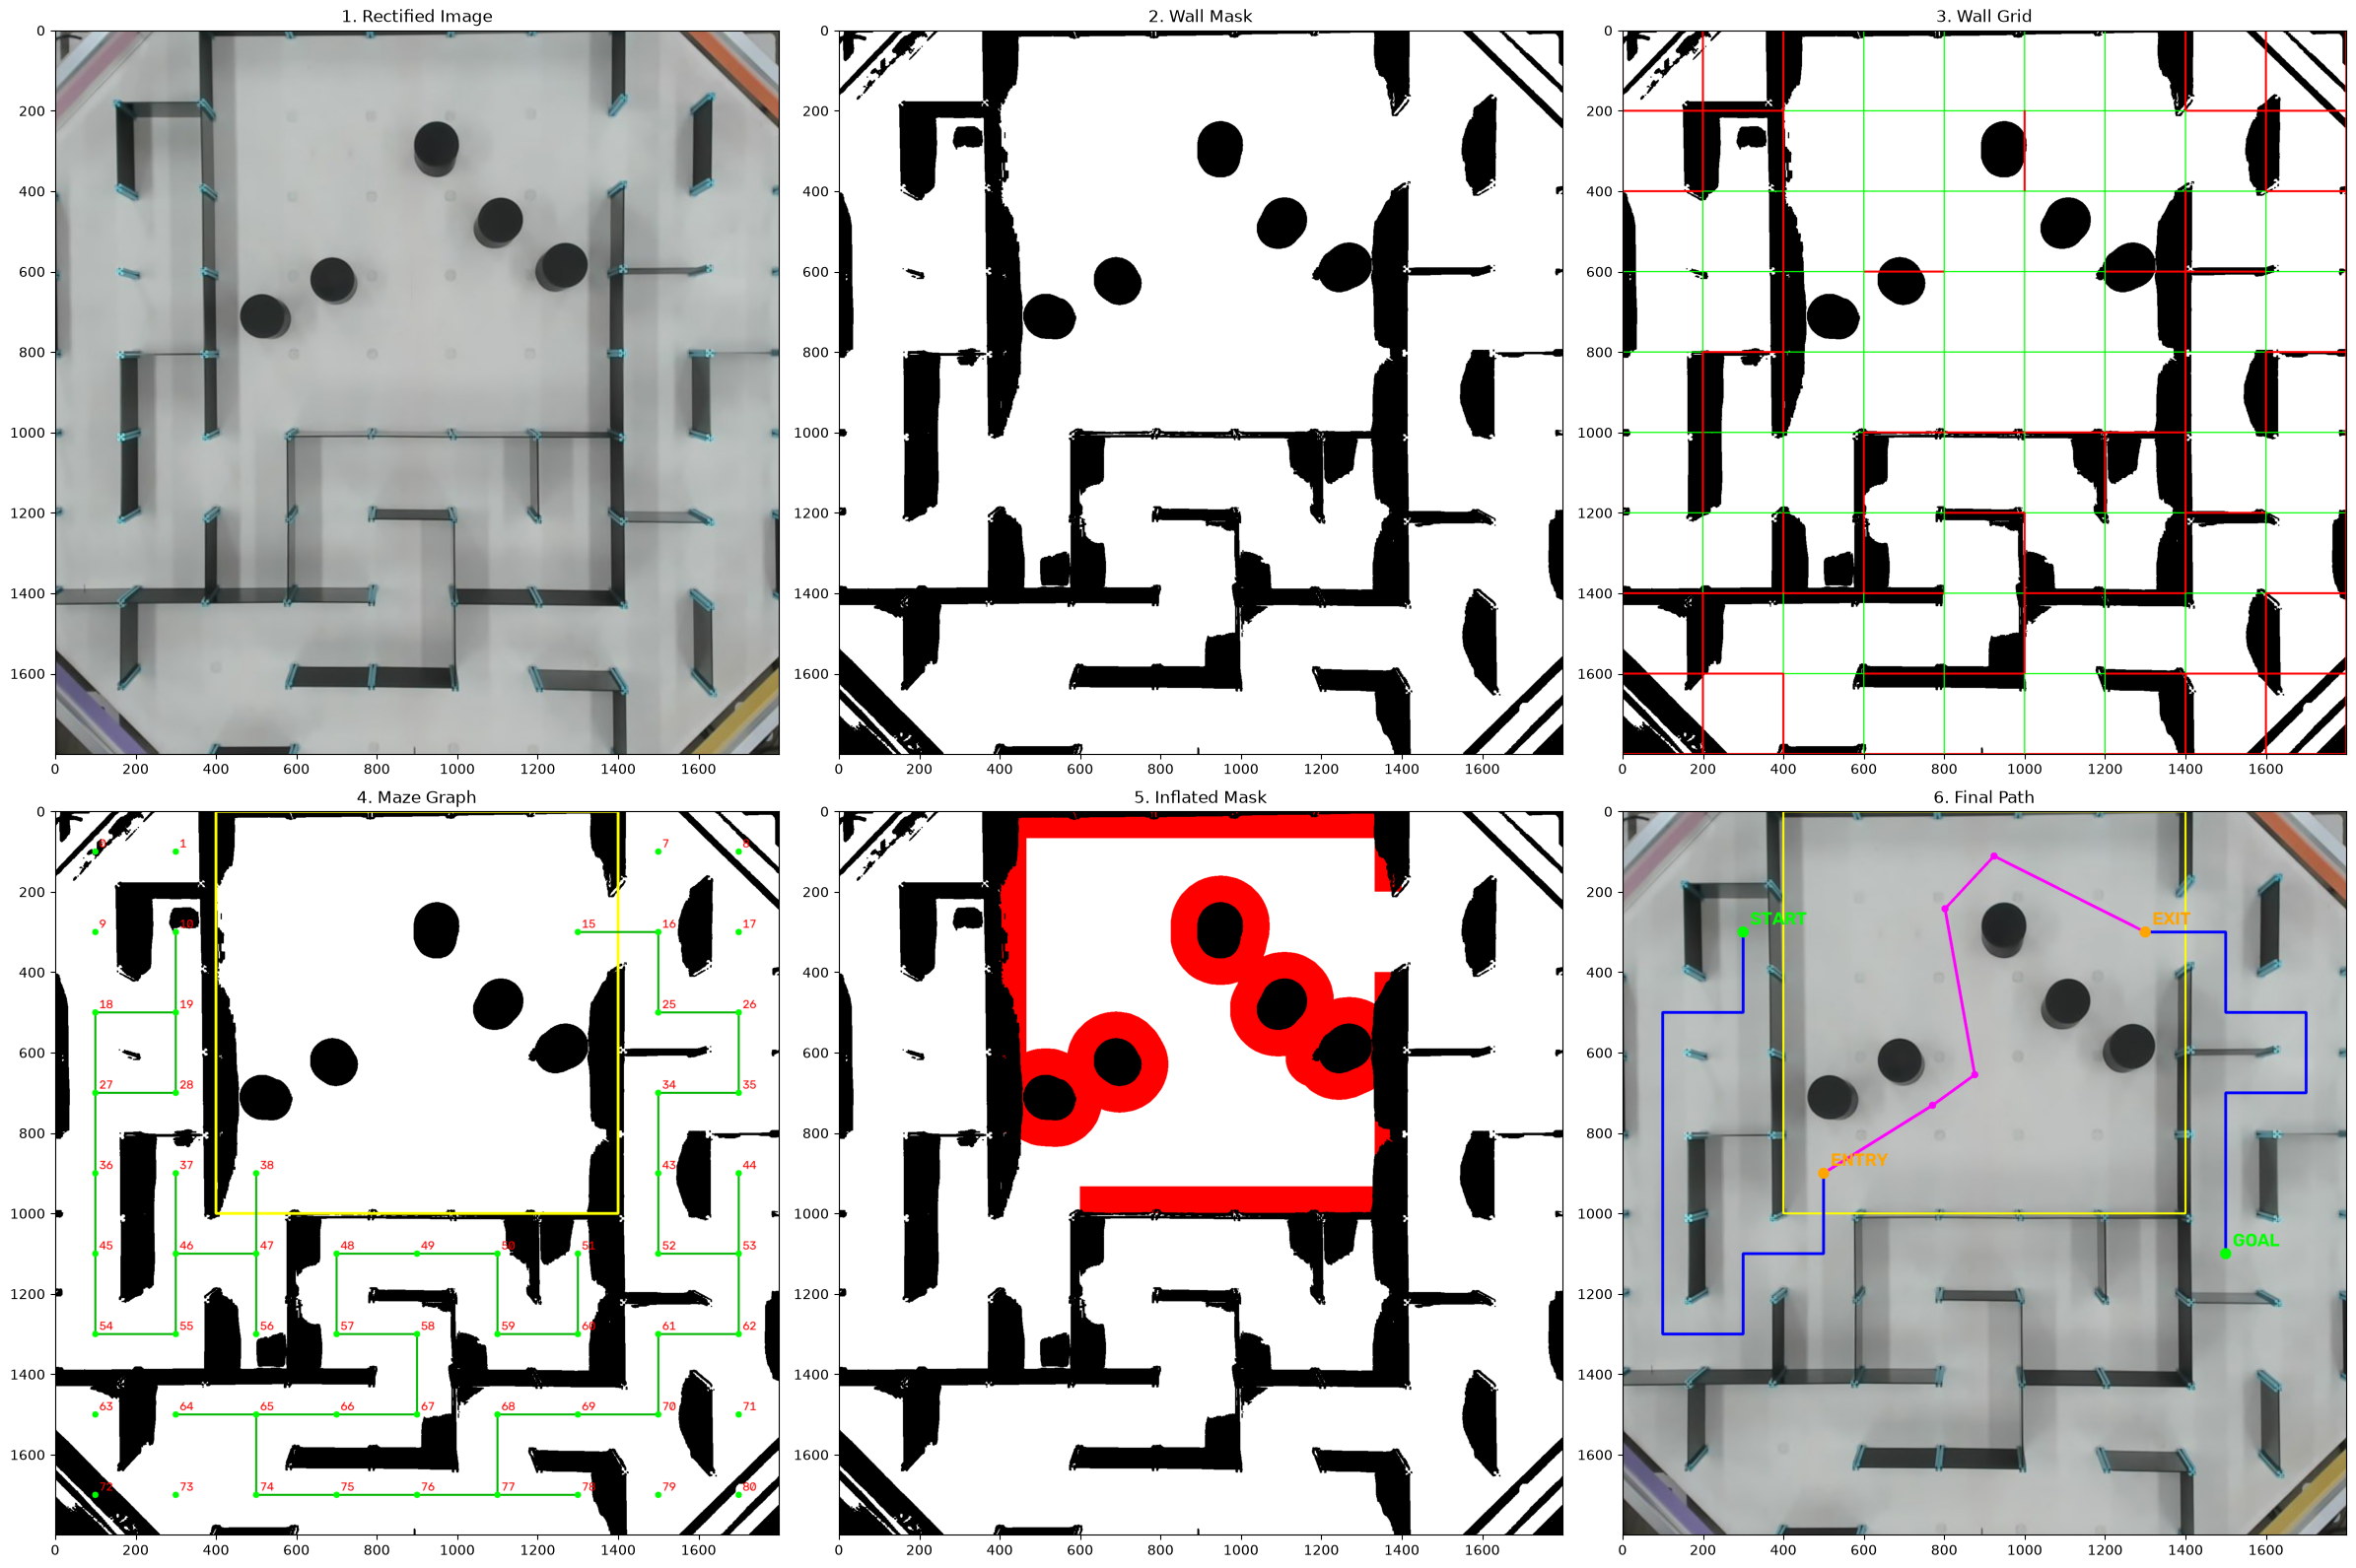

In [36]:
images = [rectified_bgr, wall_mask, wall_grid, graph_overlay, inflated_display, path_on_maze]
titles = ["1. Rectified Image", "2. Wall Mask", "3. Wall Grid", "4. Maze Graph", "5. Inflated Mask", "6. Final Path"]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)

plt.tight_layout()
plt.show()